# Deep learning models for arrhythmia detection and diagnosis

## Initialisation

In [2]:
# Imports
import os
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import pywt
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from scipy.signal import butter, filtfilt, iirnotch

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

# Initialise dictionaries to store data
lead1 = {}
lead2 = {}
annotations = {}

# Load ECG signals and annotations
for id in record_ids:
    signals, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    lead1[id] = signals[:, 0]
    lead2[id] = signals[:, 1]
    annotations[id] = annotation
            

## Data Preprocessing

### Filtering 

In [4]:
def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360, order=3):
   nyquist = 0.5 * fs
   low = lowcut / nyquist
   high = highcut / nyquist
   b, a = butter(order, [low, high], btype='band')
   filtered_signal = filtfilt(b, a, signal)
   return filtered_signal

def wavelet_denoise(signal, wavelet='db4', level=5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    coeffs[1:] = [pywt.threshold(c, np.std(c) * 0.4, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet)

def notch_filter(signal, freq=50, fs=360, quality_factor=30):
    nyquist = 0.5 * fs
    w0 = freq / nyquist
    b, a = iirnotch(w0, quality_factor)
    return filtfilt(b, a, signal)

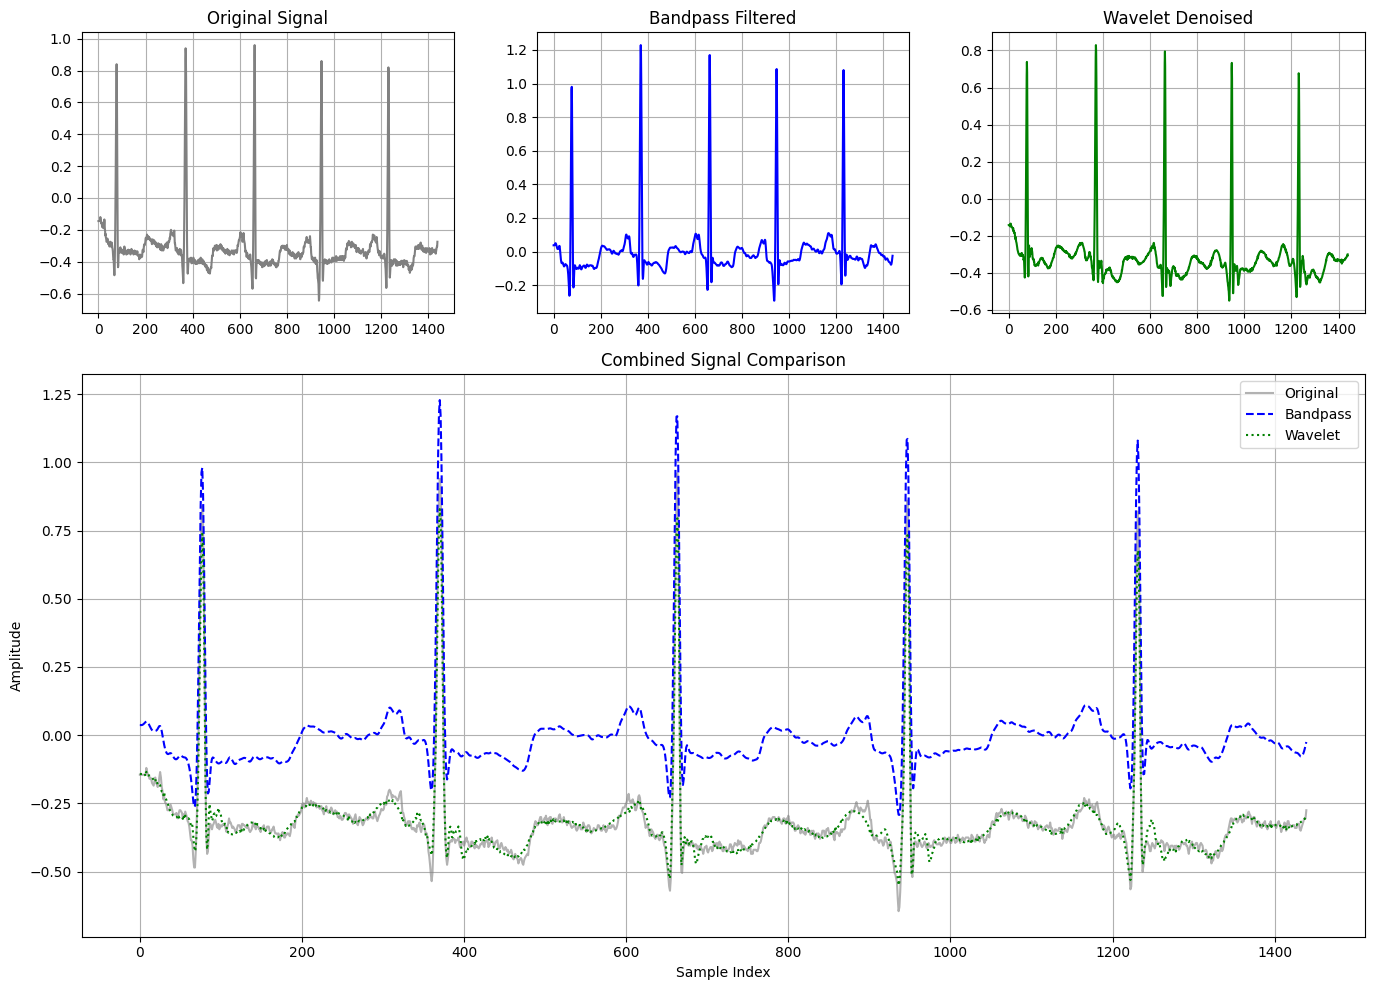

In [5]:
unfiltered = lead1[100][0: 1440]

# Apply filters
bandpass = bandpass_filter(unfiltered)
denoised = wavelet_denoise(unfiltered)

# Create a 2-row grid: 3 plots on top (1st row), 1 combined on bottom (2nd row)
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 2])  # First row small, second row bigger

# Individual plots (top row)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(unfiltered, color='gray')
ax1.set_title('Original Signal')
ax1.grid(True)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(bandpass, color='blue')
ax2.set_title('Bandpass Filtered')
ax2.grid(True)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(denoised, color='green')
ax3.set_title('Wavelet Denoised')
ax3.grid(True)

# Combined plot (bottom row)
ax4 = fig.add_subplot(gs[1, :])  # Span all 3 columns
ax4.plot(unfiltered, label='Original', alpha=0.6, color='gray')
ax4.plot(bandpass, label='Bandpass', linestyle='--', color='blue')
ax4.plot(denoised, label='Wavelet', linestyle=':', color='green')
ax4.set_title('Combined Signal Comparison')
ax4.set_xlabel('Sample Index')
ax4.set_ylabel('Amplitude')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

### Normalisation

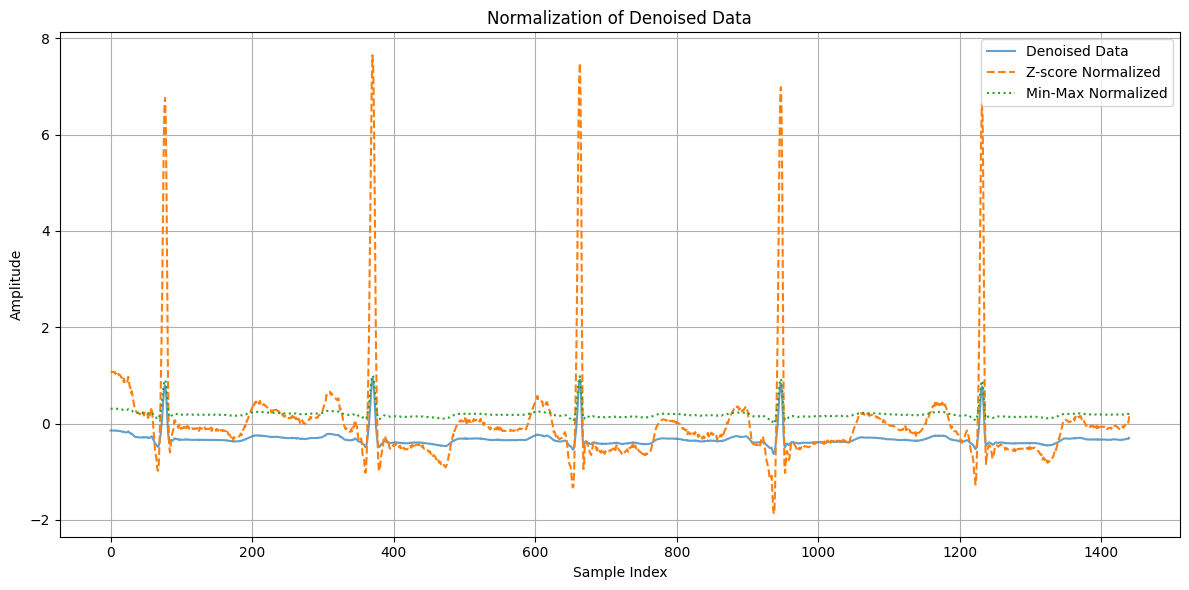

In [33]:
# Z-score normalization function
def normalize_zscore(data):
    mean_val = np.mean(data)
    std_val = np.std(data)
    return (data - mean_val) / std_val

# Min-Max normalization function
def normalize_minmax(data):
    data_min = np.min(data)
    data_max = np.max(data)
    return (data - data_min) / (data_max - data_min)

# Normalize your denoised data using both methods
zscore_normalized = normalize_zscore(denoised)
minmax_normalized = normalize_minmax(denoised)

# Plot the results for comparison
plt.figure(figsize=(12, 6))
plt.plot(denoised, label='Denoised Data', alpha=0.7)
plt.plot(zscore_normalized, label='Z-score Normalized', linestyle='--')
plt.plot(minmax_normalized, label='Min-Max Normalized', linestyle=':')
plt.title('Normalization of Denoised Data')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Segmentation

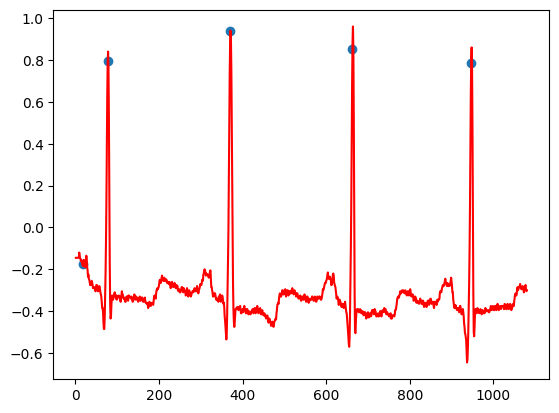

In [40]:
# Need to find R-Peak which is contained in the annotations of the file
R_location = annotations[100].sample
R_class = annotations[100].sample

# R-peak ploting
x = np.arange(1, 1081)

n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(R_location[i])
  r_peak_y.append(denoised[R_location[i]])

plt.plot(x, unfiltered[0:1080], color='red')
plt.scatter(r_peak_x, r_peak_y)
     

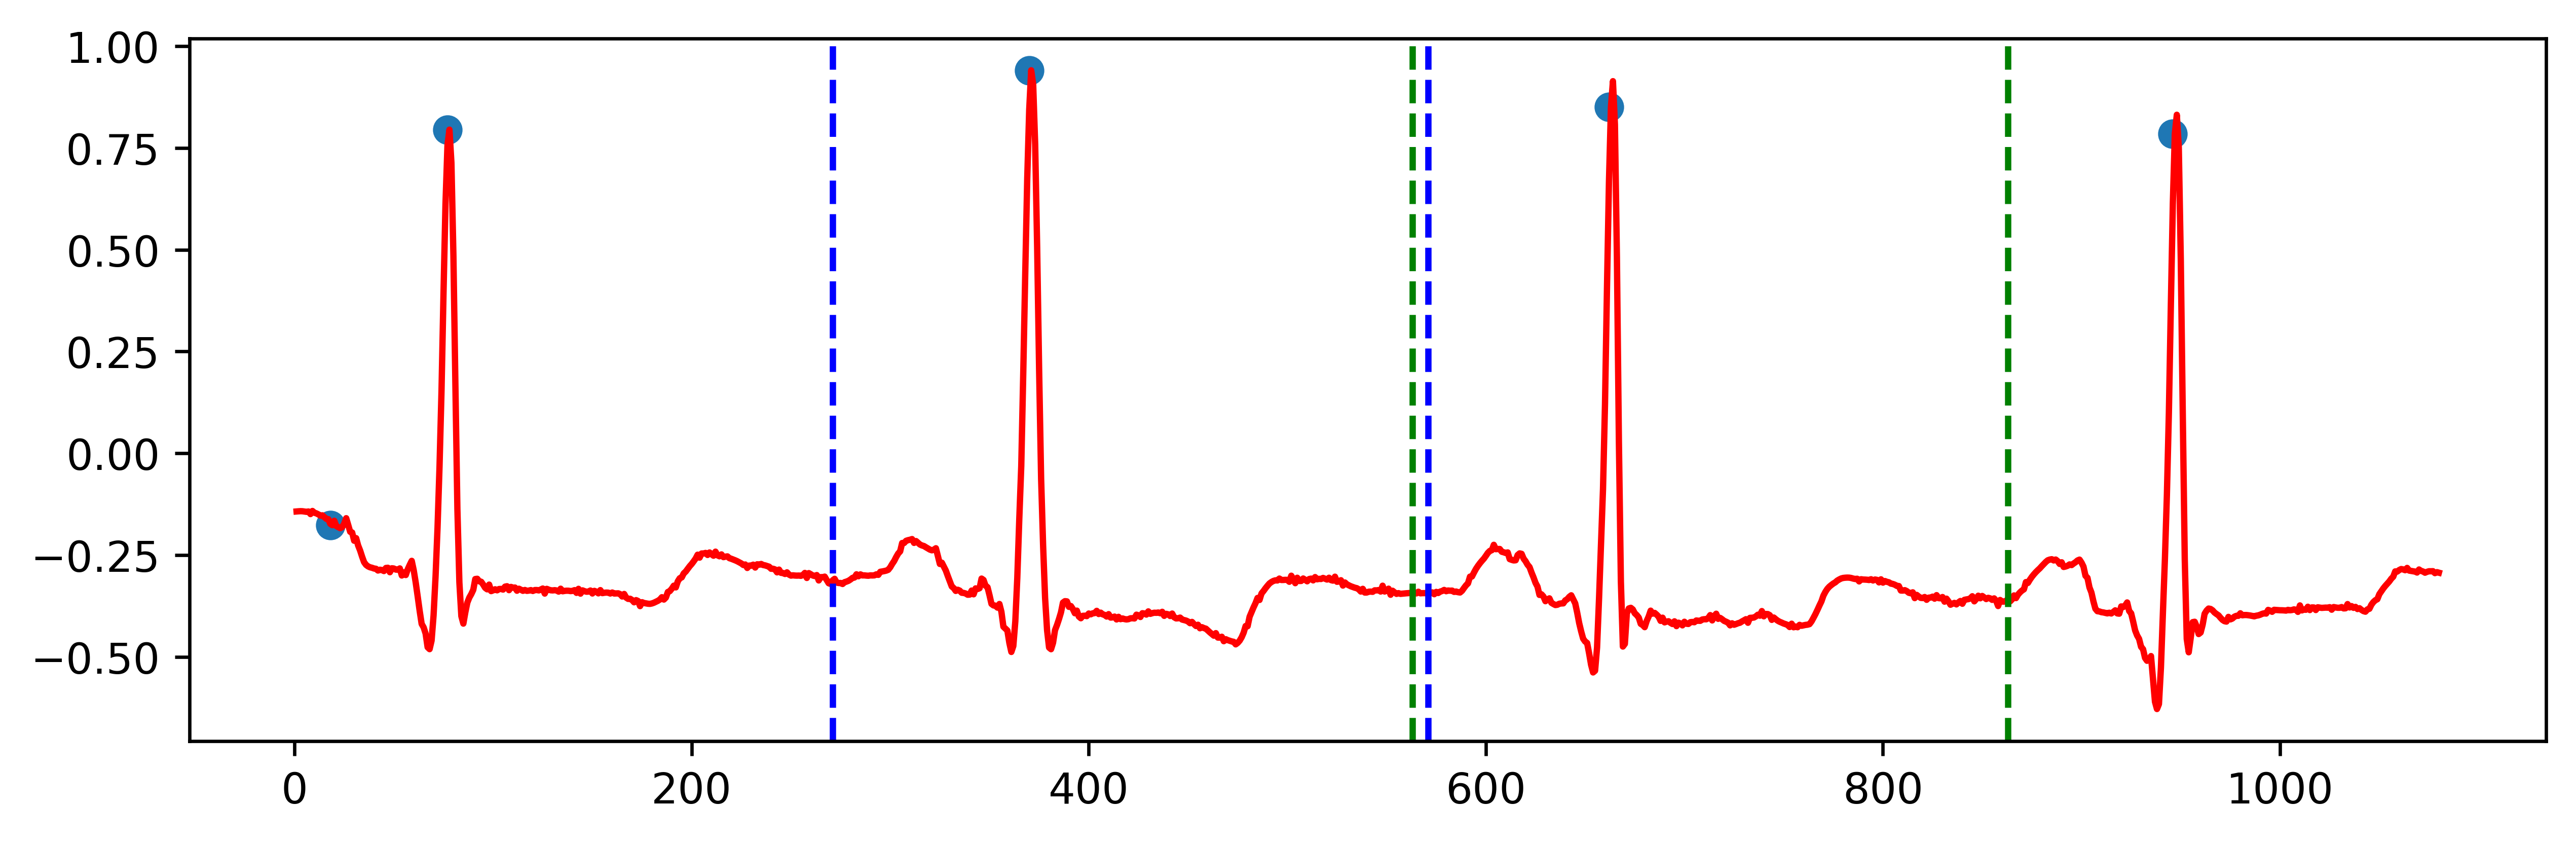

In [52]:
# split into 300 sample windows 
# Plotting R-peaks and segmentation lines
fig = plt.figure(figsize=(10,3), dpi=600)
n_peak =5
r_peak_x = []
r_peak_y = []
for i in range(0, n_peak):
  r_peak_x.append(R_location[i])
  r_peak_y.append(denoised[R_location[i]])
x = np.arange(1, 1081)
plt.plot(x, denoised[0: 1080], color='red')
plt.scatter(r_peak_x, r_peak_y)

# line plotting
plt.axvline(x = R_location[2]-99, color = 'blue', linestyle = '--') 
plt.axvline(x = R_location[2]+201, color = 'blue', linestyle = '--') 
plt.axvline(x = R_location[3]-99, color = 'green', linestyle = '--') 
plt.axvline(x = R_location[3]+201, color = 'green', linestyle = '--') 
     

## Models

### Beat Classifier

In [ ]:
class BeatClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(BeatClassifier, self).__init__()
        
        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### Signal Classifier

In [ ]:
class SignalClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SignalClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.dropout(x)
        x = self.fc(x)
        return x
    
class SignalTransformer(nn.Module):
    def __init__(self, input_size=3, d_model=64, num_heads=4, num_layers=2, num_classes=5):
        super(SignalTransformer, self).__init__()
        
        # Positional Encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, 100, d_model))  # Max sequence length = 100
        
        # Transformer Encoder Layer
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        
        # Fully Connected Layer
        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # x: Batch size x sequence length x input size
        x = x * np.sqrt(64)  # Scaling input (similar to Transformer)
        
        # Add positional encoding (optional)
        x = x + self.positional_encoding[:, :x.size(1), :]
        
        # Transformer expects input shape (seq_len, batch_size, input_size)
        x = x.permute(1, 0, 2)  # Shape: (sequence_length, batch_size, feature_size)
        
        # Pass through Transformer Encoder
        x = self.transformer(x)
        
        # Use the output of the last token
        x = x[-1, :, :]  # Only take the last token's output
        
        # Final classification
        x = self.fc(x)
        x = self.softmax(x)
        return x

### Transformer

## Training

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

## Testing

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    return correct / len(dataloader.dataset)

## Evaluation